In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
from xgboost import XGBRegressor

In [3]:
# load the dataset
data = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC']

# Prepare Features and Target
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

In [5]:
# Split the data into training, validation, and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


model= XGBRegressor(colsample_bytree=1,
                     gamma=5, 
                     learning_rate=0.1,
                     max_depth=7,
                     n_estimators=100, 
                     subsample=0.8)

# Fit the model on the training data
model.fit(X_train_scaled, Y_train)

# Predict on the training data
Y_train_pred = model.predict(X_train_scaled)

# Train metrics
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100


# Predict on the test data
Y_test_pred = model.predict(X_test_scaled)

# Test metrics (already in your code, but grouped here for clarity)
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100


# Combine both into a DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['R2', 'MAE',  'RMSE', 'MAPE'],
    'Train': [r2_train, mae_train,  rmse_train, mape_train],
    'Test': [r2_test, mae_test,  rmse_test, mape_test]
})

# Round to 3 decimal places
metrics_df[['Train', 'Test']] = metrics_df[['Train', 'Test']].round(3)

# Display the comparison
print(metrics_df)

  Metric  Train   Test
0     R2  0.972  0.938
1    MAE  1.654  2.398
2   RMSE  2.610  3.929
3   MAPE  2.477  3.753


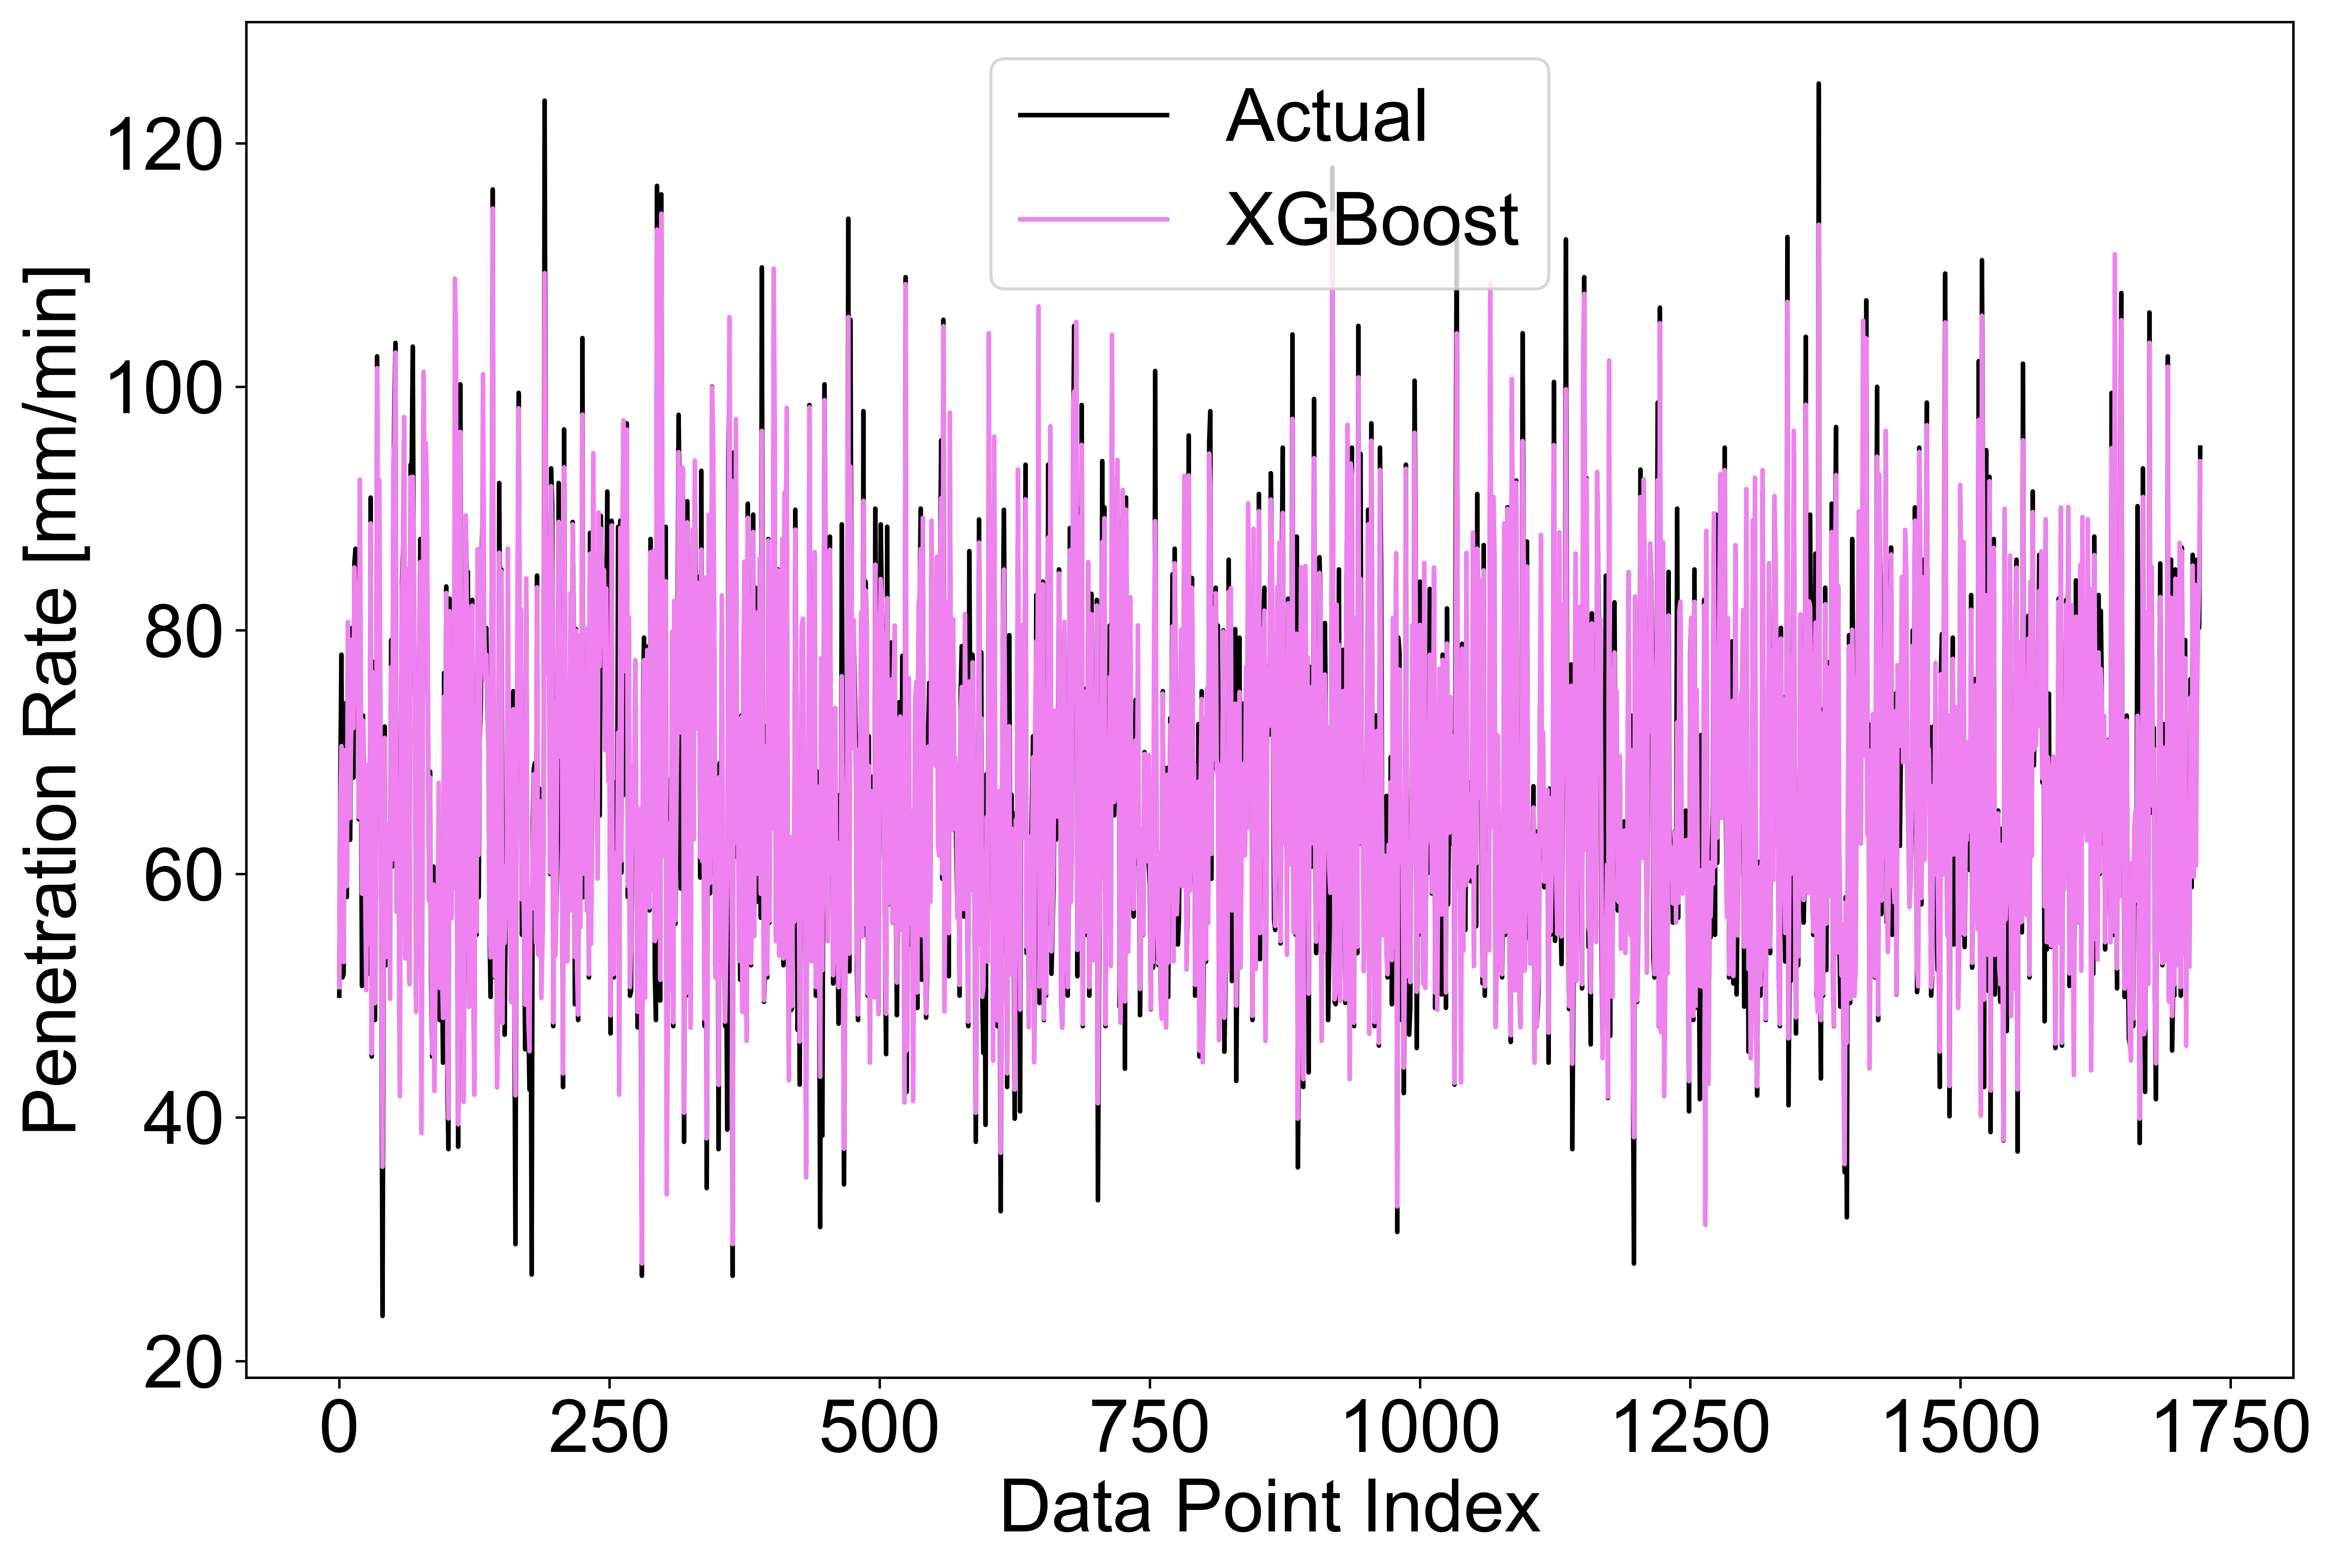

In [7]:
# Create a list of data point indices (numbers) for the entire dataset
data_indices = range(len(Y_test))

# Create a line plot of actual vs. predicted Y values for the entire dataset
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 8), dpi=800)
plt.plot(data_indices, Y_test, 'black', label='Actual')
plt.plot(data_indices, Y_test_pred, 'violet', label='XGBoost')
plt.xlabel('Data Point Index', fontsize=24)
plt.ylabel('Penetration Rate [mm/min]', fontsize=24)
#plt.title('Actual vs. Predicted Compressive strength by RF Model', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(loc='best', fontsize=24)
plt.show()

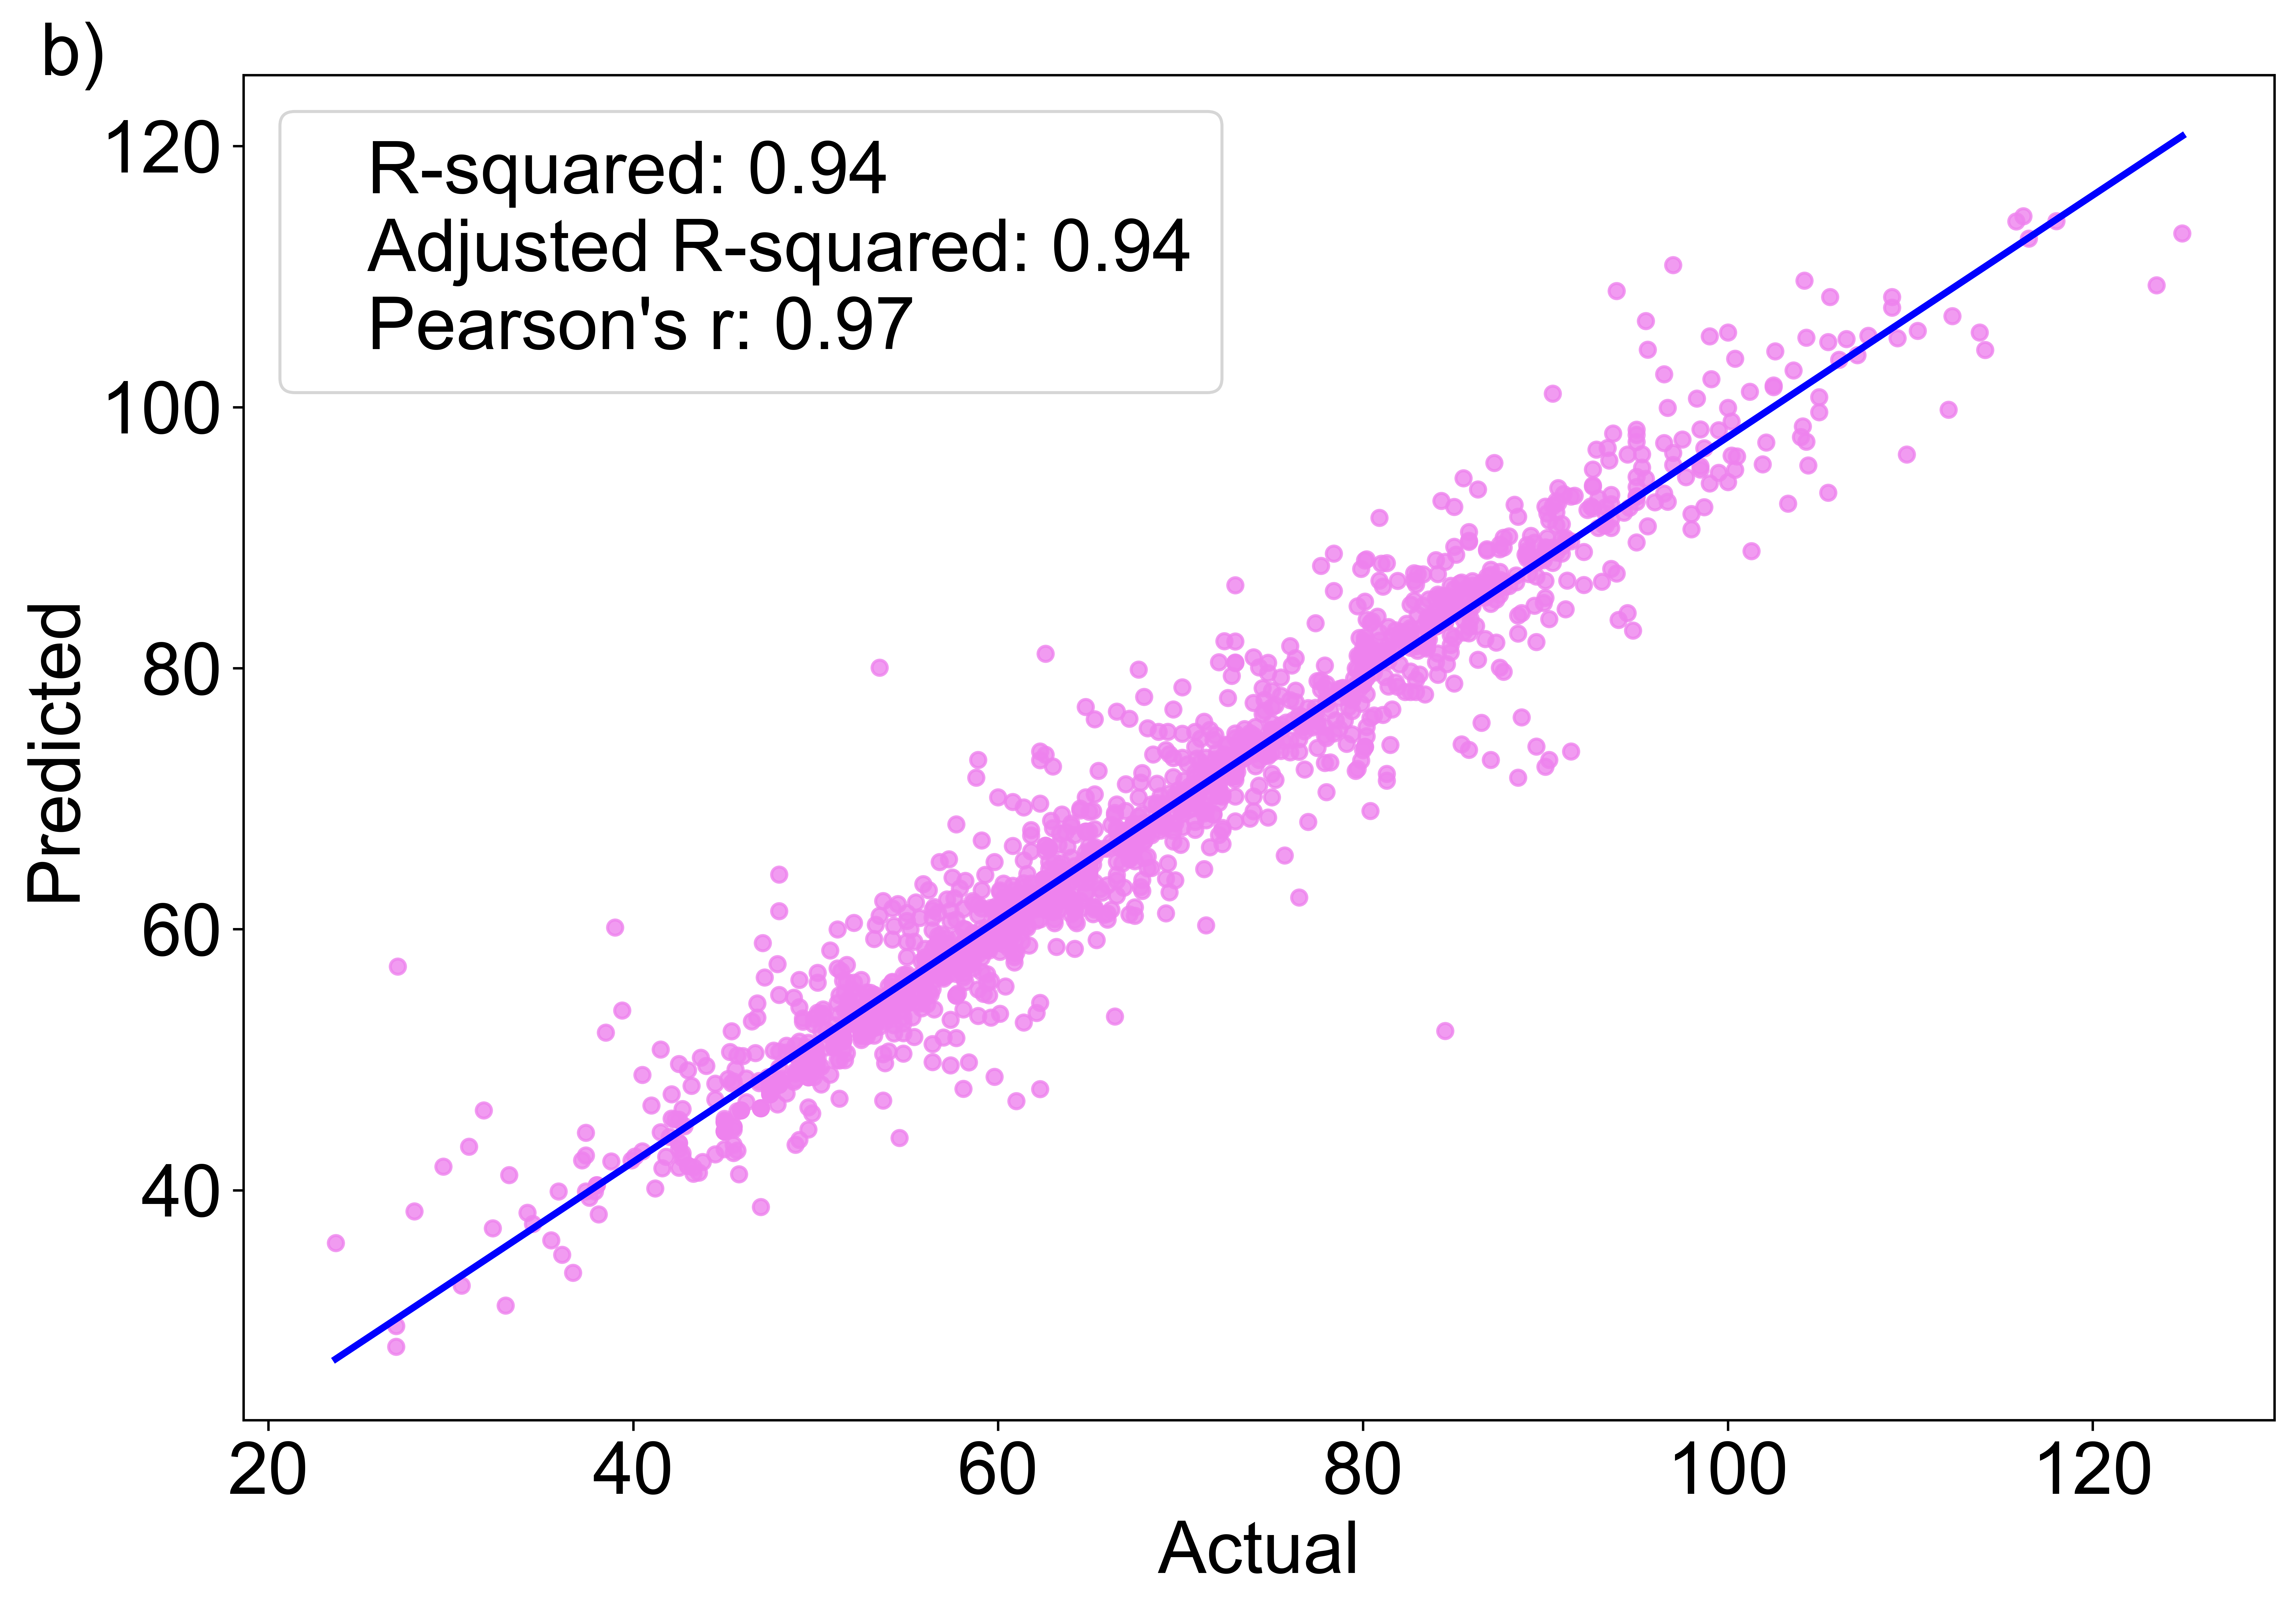

In [19]:
# Calculate additional evaluation metrics
r2 = r2_test
correlation, _ = pearsonr(Y_test, Y_test_pred)
adjusted_r2 = 1 - (1 - r2) * ((len(Y_test) - 1) / (len(Y_test) - X.shape[1] - 1))

# Create a scatter plot with a linear regression line
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 8), dpi=800)
sns.regplot(x=Y_test, y=Y_test_pred, ci=None,
            scatter_kws={'s': 25, 'color': 'violet'}, line_kws={'color': 'blue'})
plt.xlabel('Actual', fontsize=24)
plt.ylabel('Predicted', fontsize=24)
plt.text(-0.1, 1, 'b)', fontsize=24, transform=plt.gca().transAxes)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Add R-squared, adjusted R-squared, and Pearson's r to the upper-left corner of the plot
legend_text = f'R-squared: {r2:.2f}\nAdjusted R-squared: {adjusted_r2:.2f}\nPearson\'s r: {correlation:.2f}'
plt.legend([legend_text], loc='upper left', fontsize=24, handlelength=0, markerscale=0)
# Save the figure
plt.savefig('scatter_plot.png', bbox_inches='tight')
plt.show()